In [1]:
import catalogue_analysis as ca
import redshift_weights as rw
import numpy as np
from astropy.table import join,Table,Column,vstack,setdiff,unique
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:


######################################################################################################################
# Select list of catalogues on which analysis is based
FileSet = 'Y3'
info = True              #choose whether to echo stats on each dataset
fresh_kcorr = False       #choose whether to recompute k-corrections and restframe colours or use existing tables
plot = True            #set to false if you don't want so many diagnostic plots
PhotometryMatch =  False #Empircally debias N colours and S magnitudes
UseBetterSGARedshifts = False #Use SGA redshift where they appear better than DESI redshifts
construct_vacshape = False  #Read in all the VAC catalogues to construct the summary vacshape table rather than use pre-existing
UseCosmicRedshift  = True     #Compute Flow Corrected CMB redshift and select sample on this rather than the default Heliocentric redshift   
OutputCatalogue = "sdata/BGS_Y3_15April2026.fits"  #File into which to save the Augmented Catalogue
UsePetrosian = False

######################################################################################################################

if (FileSet == 'Y1'):
  #Load the catalogue  (set fpath as required)
  fpathN='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_N_clustering.dat.fits' #clustering catalogue north
  fpathS='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_S_clustering.dat.fits' #clustering catalogue south
  #load clustering catalogue  (Y1 was in two parts which we concaternate)
  datall=ca.load_catalogues(fpathN,fpathS)
  fullfile='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_full.dat.fits'  # full observed catalogue used for redshift weights 
  fsffile='./data/fastspec-iron-main-bright.fits' #fsf file used for k-corrections  
elif (FileSet == 'Y3'):
  fpath='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/BGS_BRIGHT_clustering.dat.fits' #clustering catalogue
  #old version #fpath='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/nonKP/BGS_BRIGHT_clustering.dat.fits' #clustering catalogue
  datall=ca.Y3load_catalogues(fpath)
  #Load clustering catalogue  
  # old version #fullfile='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/BGS_BRIGHT_full_HPmapcut.dat.fits'
  fullfile='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/BGS_BRIGHT_full_HPmapcut.dat.fits' #full observed catalogue used for redshift weights 
  fsffile='./data/fastspec-iron-main-bright.fits' #fsf file used for k-corrections  
else:
  print('Set of files on which analysis is to be based is not specified')


if (info):
    print('Statistics of the clustering catalogue:')
    datall.info('stats')    

if UseBetterSGARedshifts:  #Use the small catalogue for which SGA redshifts appear better than DESI redshifts to replace the DESI redshift
    print('Using some SGA redshifts in place of DESI redshifts')
    sgabetter=Table.read('sdata/SGAbetter.fits')
    sgabetter.info('stats')
    mask = (sgabetter['TARGETID']==39633286472928387) 
    print('SGA entry for object 39633286472928387')
    cols= [ 'TARGETID', 'RA_LEDA', 'DEC_LEDA', 'Z_LEDA' ]
    print(sgabetter[cols][mask])
    # For objects in the dat table find their match by TARGETID with those in the sgabetter table
    # (Unmatched objects have matched=false and indx_sgabetter=-1)
    indx_sgabetter,matched=ca.link_indices_by_key(datall,sgabetter, key='TARGETID', assume_unique=True)
    datall['Z'][matched]=sgabetter['Z_LEDA'][indx_sgabetter][matched] 
    mask = (datall['TARGETID']==39633286472928387) 
    print('updated entry for object 39633286472928387')
    cols= [ 'TARGETID',  'Z' ]
    print(datall[cols][mask])

if UseCosmicRedshift:
    #Store the original redshift as ZHelio
    datall.add_column(Column(name='ZHelio', data= (datall['Z'])))
    #Compute Local Group frame redshift
    ca.z_tozLG(datall)
    # Compute Flow corrected CMB redshifts
    ca.z_tozCMB(datall, CosmicFlowCorrect=True)
    datall['Z']=datall['Zcos'] #Temporarily make this the default redshift to apply the redshift cuts
else:
    datall['Zcos']=datall['Z'] #use the one default redshift for everything


#Specify regions to loop over
regions=('N', 'S')


#Random sample and apply all cuts from the start for a quick run through
Sel=ca.selection('N')# import North selection cuts  
smaskN= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) & (np.random.rand(datall['Z'].size)<Sel['f_ran'])\
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='N') 
Sel=ca.selection('S') # import South selection cuts    
smaskS= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) &(np.random.rand(datall['Z'].size)<Sel['f_ran']) \
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='S')
smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
dat=datall[smask].copy()
del datall
print('South sample size:',smaskS.sum())
print('North sample size:',smaskN.sum())

if UseCosmicRedshift: 
    dat['Z']=dat['ZHelio'] #Revert the default back to ZHelio for using in computing k-corrections

if (info):
    print('Statistics of the data catalogue after applying the selection cuts:')
    dat.info('stats')


Statistics of the clustering catalogue:
<Table length=7875016>
      name           mean        std         min          max    
---------------- ----------- ----------- ------------ -----------
        TARGETID 3.96297e+16  2.4855e+12  3.96273e+16 3.96374e+16
          TILEID     23114.2     1881.87        20000       27852
               Z    0.213348    0.104266   0.00200098     0.59999
           NTILE     2.43434    0.916933            1           5
              RA     183.077      91.251  0.000108207         360
             DEC     21.9898     23.0655     -19.5559     79.2584
         PHOTSYS          --          --           --          --
FRAC_TLOBS_TILES    0.984397   0.0270119     0.333333           1
    WEIGHT_ZFAIL     1.00127  0.00523184            1     1.19871
      BITWEIGHTS -5.2572e+14 3.02575e+18 -9.22337e+18 9.22337e+18
        PROB_OBS    0.855099    0.209398            0           1
          WEIGHT      1.2907    0.768013            1          72
     WEIGHT_C

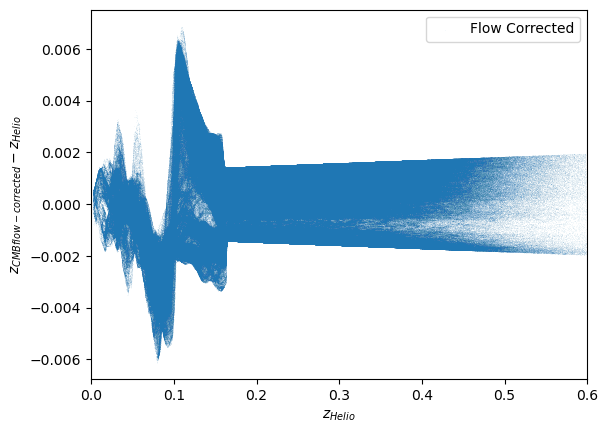

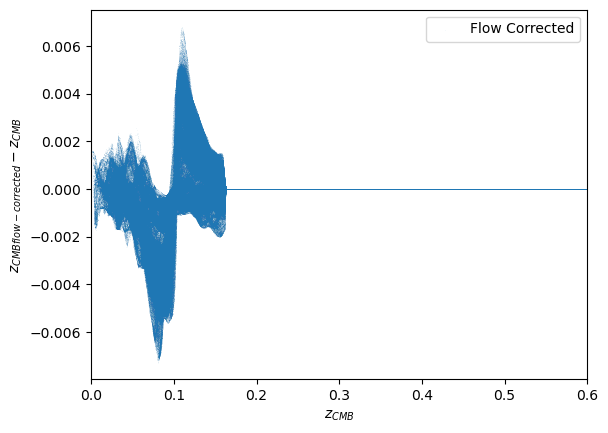

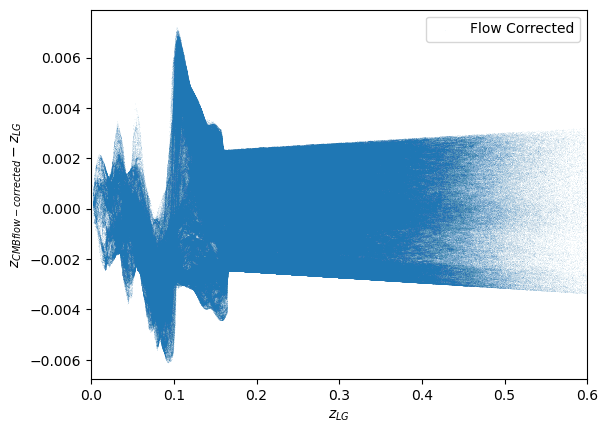

In [3]:
# Plots to compare different redshift definitions
if UseCosmicRedshift & plot : 
    %config InlineBackend.figure_format = 'png'
    # Difference between flow corrected zCMB and zHelio
    plt.scatter(dat['ZHelio'],dat['Zcos']-dat['ZHelio'], marker='.',linewidths=0,s=0.25,alpha=0.2,label='Flow Corrected',rasterized=True)
    plt.xlim([0.0,0.6])
    #plt.ylim([0.0,0.6])
    plt.ylabel('$z_{CMB flow-corrected}-z_{Helio}$')
    plt.xlabel('$z_{Helio}$')
    plt.legend()
    plt.show()
    
    # Difference between flow corrected zCMB and zCMB
    plt.scatter(dat['ZCMB'],dat['Zcos']-dat['ZCMB'], marker='.',linewidths=0,s=0.25,alpha=0.2,label='Flow Corrected',rasterized=True)
    plt.xlim([0.0,0.6])
    #plt.ylim([0.0,0.6])
    plt.ylabel('$z_{CMB flow-corrected}-z_{CMB}$')
    plt.xlabel('$z_{CMB}$')
    plt.legend()
    plt.show()
    
    # Difference between flow corrected zCMB and zLG
    plt.scatter(dat['ZLG'],dat['Zcos']-dat['ZLG'], marker='.',linewidths=0,s=0.25,alpha=0.2,label='Flow Corrected',rasterized=True)
    plt.xlim([0.0,0.6])
    #plt.ylim([0.0,0.6])
    plt.ylabel('$z_{CMB flow-corrected}-z_{LG}$')
    plt.xlabel('$z_{LG}$')
    plt.legend()
    plt.show()

Using pre-computed colour look-up and k-correction polynomials
Computing restframe colours for region  N using lookup for region  N
using precomputed k-corrections
LOADING IN LOOKUP TABLE


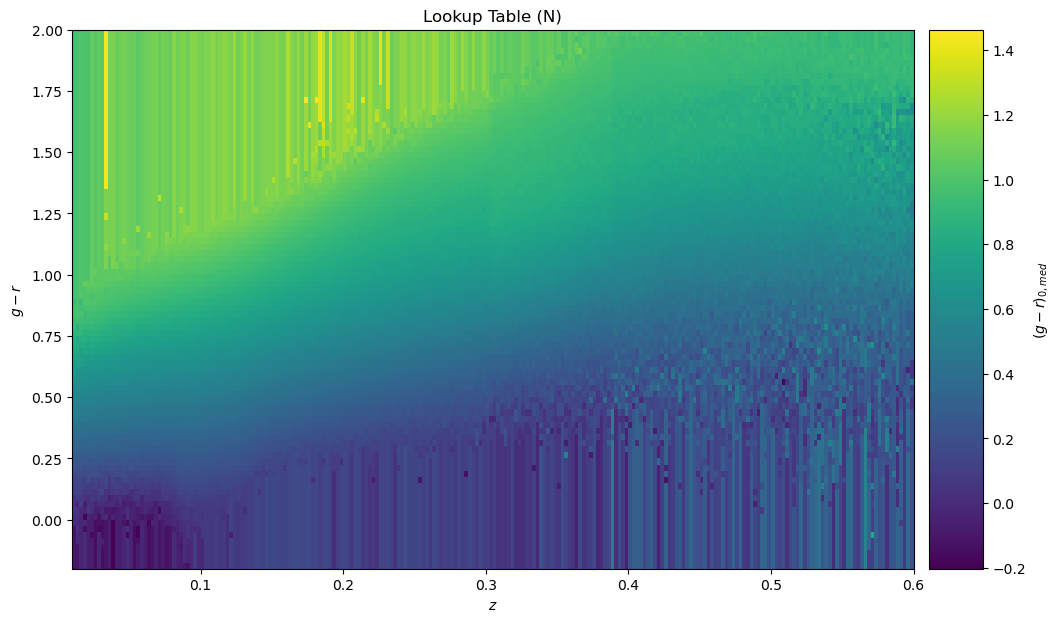

REST-FRAME COLOURS ASSIGNED.
Reading k-correction polynomials from  .//data//jmext_kcorr_N_w1band_z01.dat
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0013695368084338947
Reading k-correction polynomials from  .//data//jmext_kcorr_N_zband_z01.dat
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0013695368084338947
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0013695368084338947
Reading k-correction polynomials from  .//data//jmext_kcorr_N_gband_z01.dat
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0013695368084338947
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Computing restframe colours for region  S using lookup for region  S
using precomputed

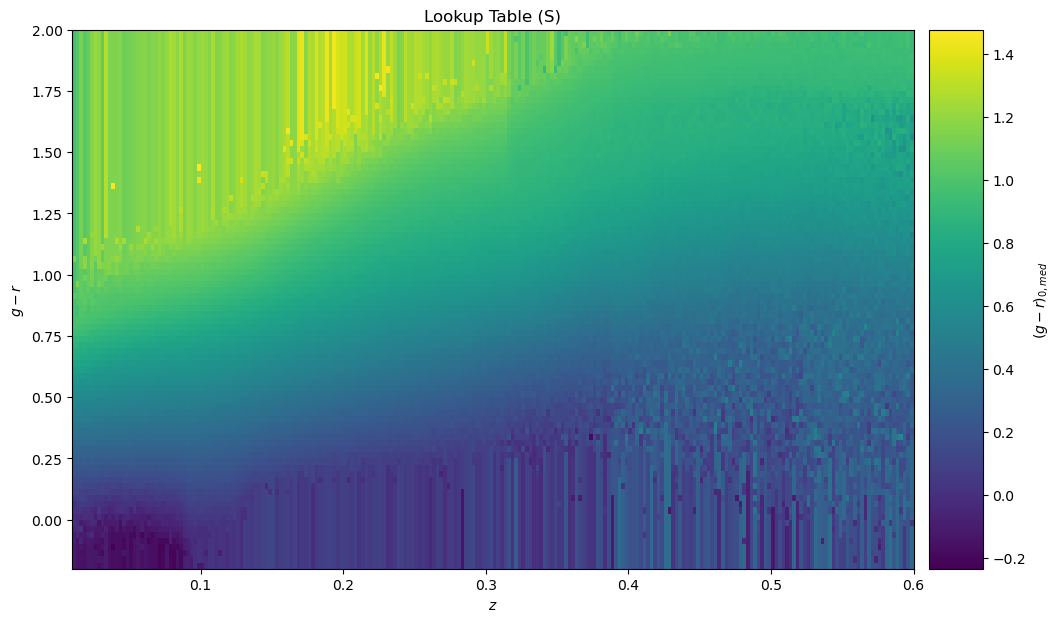

REST-FRAME COLOURS ASSIGNED.
Reading k-correction polynomials from  .//data//jmext_kcorr_S_w1band_z01.dat
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0017049815021250856
Reading k-correction polynomials from  .//data//jmext_kcorr_S_zband_z01.dat
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0017049815021250856
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0017049815021250856
Reading k-correction polynomials from  .//data//jmext_kcorr_S_gband_z01.dat
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0017049815021250856
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Statistics of the data catalogue after computing and adding rest frame colours and abs

In [4]:
# If you want to recompute the colour lookup table and k-correction polynomials set fresh=True otherwise re-use stored table and fits
fresh = fresh_kcorr

if (fresh == True) :
  print('Recomputing colour look-up and k-correction polynomials')
  # Read John Moustakas's Fast Spec Catalogue
  fsf=ca.read_fsf(fsffile)
  print('statistics of the Fast Spectral Fitting Catalogue used for k-correction')
  fsf.info('stats')
  if PhotometryMatch :   #Force North to agree with South rest frame colour distribution
      print('Forcing South to agree with North rest frame colour distribution')
      fsf=ca.remapfsf_rmags(fsf,plot=plot)
      print('Statistics of modified FSF catalogue after forcing rest frame colour distributions to agree:')
      fsf.info('stats')
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=fresh,plot=plot)  
  del fsf # tidy up  
else:
  fsf='null' #just defining the variable so code doesn't complain  
  print('Using pre-computed colour look-up and k-correction polynomials')
  #compute rest frame colours and absolute magnitudes using k-corrections already computed from the fsf catalogue
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=False,plot=plot)

if UseCosmicRedshift:       #Now switch back to cosmic redshift for everything else 
    dat['Z']=dat['Zcos']    

if (info):
   print('Statistics of the data catalogue after computing and adding rest frame colours and absolute magnitudes:')
   dat.info('stats')

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat


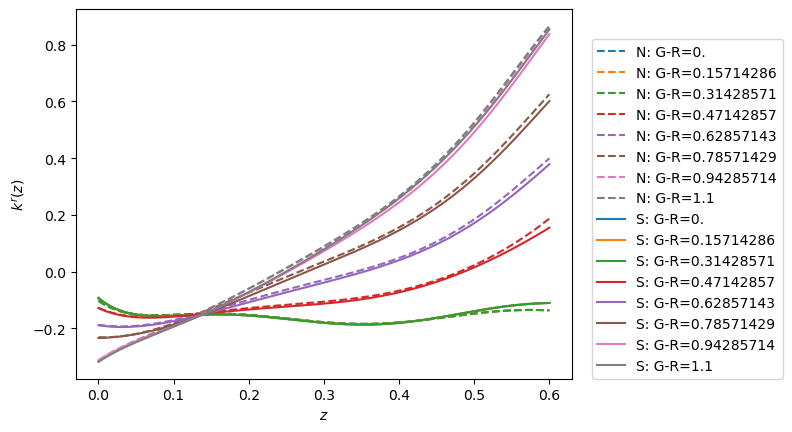

In [5]:
#Plot k-corrections to check they are well behaved
if plot :
    ca.plot_kcorr(regions)

In [6]:
#
if PhotometryMatch : #Force absolute magnitude distribution of South to agree with North
   print('Forcing absolute magnitude distribution of South to agree with North')
   dat=ca.remap_rmags(dat,plot=plot)
   # As magnitudes have changed we have to reimpose the selection (we can do this and keep a complete sample if all the shifts make objects fainter)
   Sel=ca.selection('N')# import North selection cuts  
   smaskN= (dat['Z'] > Sel['zmin']) & (dat['Z'] < Sel['zmax']) \
   & (dat['rmag'] < Sel['faint'])  & (dat['rmag'] > Sel['bright']) & (dat['reg']=='N') 
   Sel=ca.selection('S') # import South selection cuts    
   smaskS= (dat['Z'] > Sel['zmin']) & (dat['Z'] < Sel['zmax']) \
   & (dat['rmag'] < Sel['faint'])  & (dat['rmag'] > Sel['bright']) & (dat['reg']=='S')
   smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
   dat=dat[smask]    
   print('South sample size:',smaskS.sum())
   print('North sample size:',smaskN.sum())

Using healpix map with NSIDE=32 and pixel area 3.357 sq.deg.


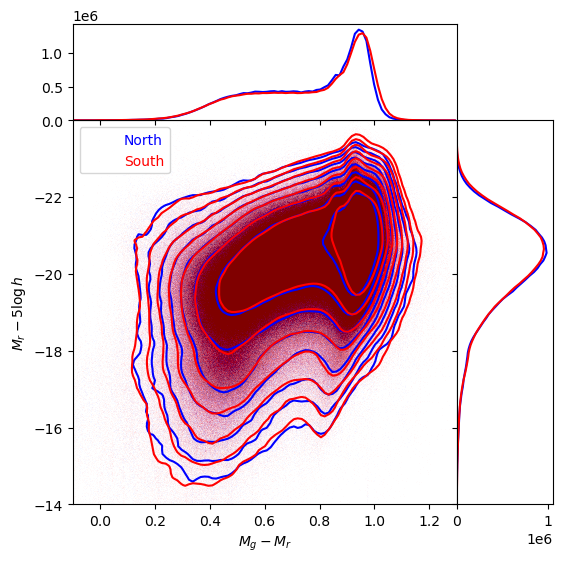

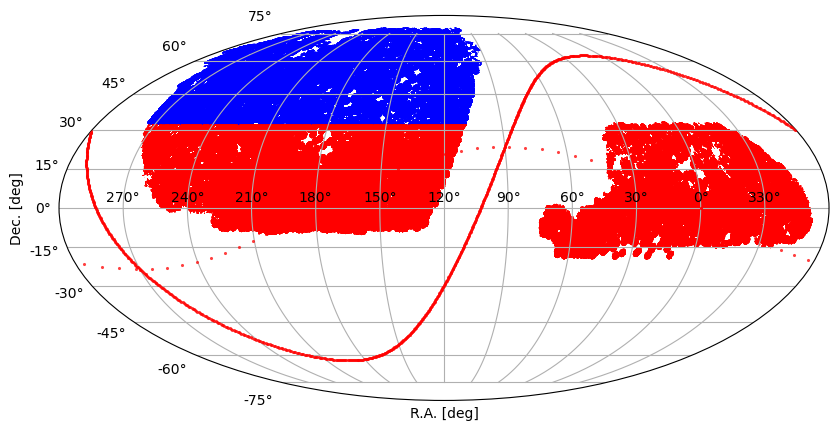

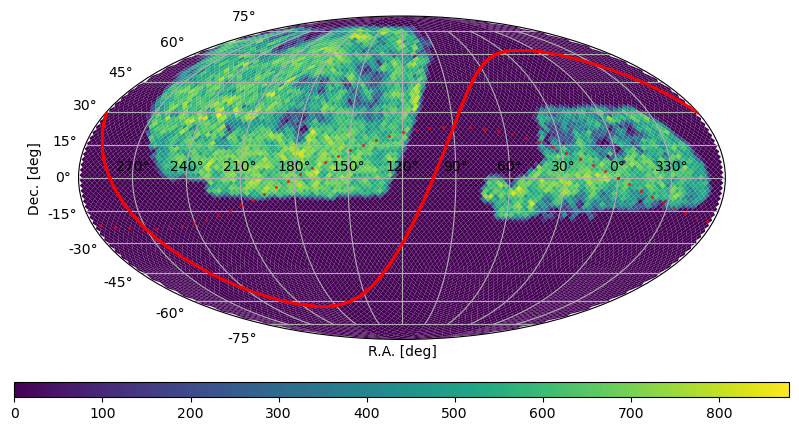

In [7]:
if plot:
    #colour-magnitude distributions
    ca.plot_col_mag(dat,regions)
    #sky plot
    ca.sky_plot(dat,regions)

Size of Full catalogue 10631484
Faintest Fibre mag: 25.411306 NB BGS was limited to r_fib=23 in an earlier version of the photometry
number of objects in the observed subset 10586812
number of objects in the good redshift subset 7917844
Faintest Observed Fibre mag: 25.411306
Statistics of the observed catalogue:
<Table length=10586812>
       name           mean        std         min         max    
----------------- ----------- ----------- ----------- -----------
         TARGETID 3.96297e+16 2.48239e+12 3.96273e+16 3.96374e+16
       Z_not4clus      243378      429121 2.14504e-08      999999
            ZWARN      243378      429121           0      999999
        DELTACHI2      244988      428310 0.000105619 3.96055e+06
        TSNR2_BGS      244635      428408        1000      999999
      GOODHARDLOC           1           0           1           1
        MORPHTYPE          --          --          --          --
              EBV   0.0415922   0.0264603  0.00254249     0.35902
  

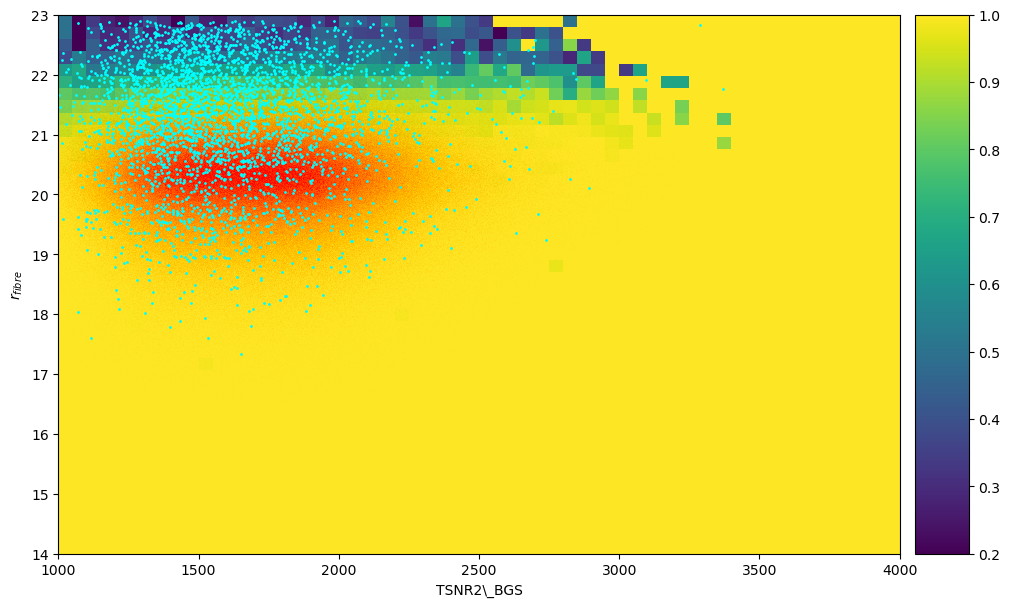

faint sample: TSNR2_BGS
---------
2342.5574
2317.8203
2043.5984
2037.5675
1956.4156
2597.6484
1984.6816
 2465.186
  2404.31
2031.2747
      ...
1272.7258
1452.9692
1309.5533
1442.5807
1234.4558
 1332.799
1672.3894
1255.1194
1885.9557
 1829.697
 1663.999
Length = 3073 rows  fib_rmag
---------
21.519596
 22.24882
21.997889
21.810257
 22.73592
 20.94488
21.382826
 22.36217
22.536873
21.691093
      ...
20.792154
21.149216
 21.31018
21.472687
21.029707
20.957548
20.849958
22.023945
 22.60052
 21.11145
21.584818
Length = 3073 rows


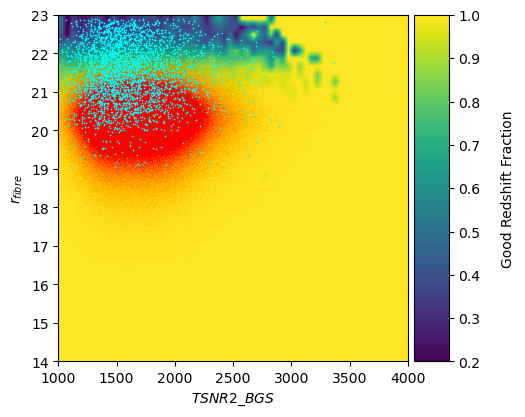

LOOK-UP TABLE GENERATED AND SAVED.
number of observed objects in region and covered by the grid 5530253
S : missed and unrepresented objects 16.0
The following plots are the raw look-up table and as seen with CIC interpolation:
faint sample: TSNR2_BGS
---------
1508.3804
2342.5574
2023.6228
2317.8203
2043.5984
2037.5675
1956.4156
2597.6484
1984.6816
 2465.186
      ...
1452.9692
1309.5533
1442.5807
1234.4558
 1614.255
 1332.799
1672.3894
1255.1194
1885.9557
 1829.697
 1663.999
Length = 3526 rows  fib_rmag
---------
19.561413
21.519596
19.917398
 22.24882
21.997889
21.810257
 22.73592
 20.94488
21.382826
 22.36217
      ...
21.149216
 21.31018
21.472687
21.029707
19.715652
20.957548
20.849958
22.023945
 22.60052
 21.11145
21.584818
Length = 3526 rows


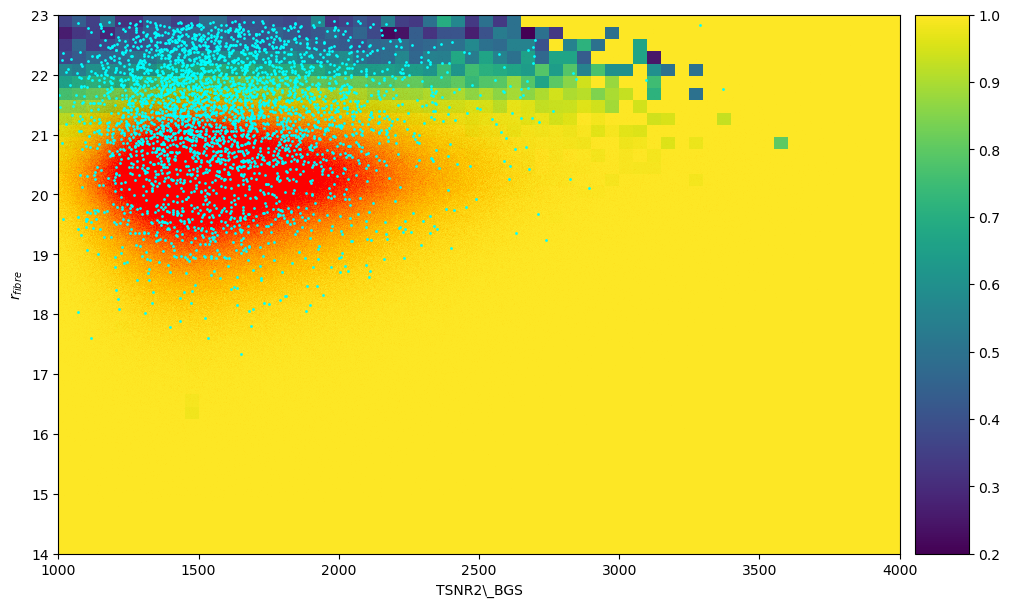

faint sample: TSNR2_BGS
---------
2342.5574
2317.8203
2043.5984
2037.5675
1956.4156
2597.6484
1984.6816
 2465.186
  2404.31
2031.2747
      ...
1272.7258
1452.9692
1309.5533
1442.5807
1234.4558
 1332.799
1672.3894
1255.1194
1885.9557
 1829.697
 1663.999
Length = 3073 rows  fib_rmag
---------
21.519596
 22.24882
21.997889
21.810257
 22.73592
 20.94488
21.382826
 22.36217
22.536873
21.691093
      ...
20.792154
21.149216
 21.31018
21.472687
21.029707
20.957548
20.849958
22.023945
 22.60052
 21.11145
21.584818
Length = 3073 rows


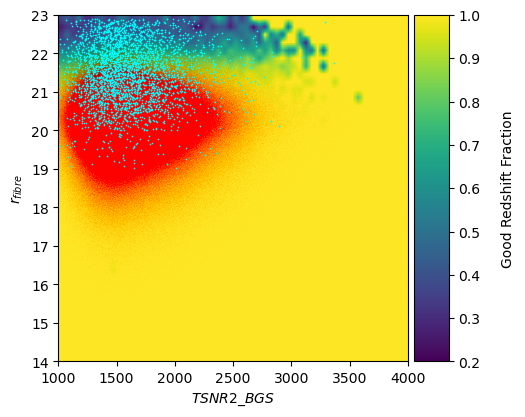

LOOK-UP TABLE GENERATED AND SAVED.
<Table length=7874903>
      name           mean         std         min          max    
---------------- ------------ ----------- ------------ -----------
        TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
          TILEID      23114.2     1881.87        20000       27852
               Z     0.213476    0.104427   0.00200603    0.599956
           NTILE      2.43434    0.916934            1           5
              RA      183.078     91.2515  0.000108207         360
             DEC      21.9899     23.0655     -19.5559     79.2584
         PHOTSYS           --          --           --          --
FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
    WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
      BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
        PROB_OBS       0.8551    0.209397            0           1
          WEIGHT       1.2907    0.768004            1          72
    

In [8]:
# Read full observed catalogue and extract the observed (meeting certain cuts) and zgood (also has good redshift) subsets 
zgood,observed,full= ca.load_full_catalogue_subsets(fullfile)
if (info):
    print('Statistics of the observed catalogue:')
    observed.info('stats')
    print('Statistics of the zgood catalogue:')
    zgood.info('stats')




# Construct the redshift weight table and add the fibmag and TSNR2_BGS columns to the data catalogue
dat=rw.construct_weight_table(dat, full, observed, zgood, plot=plot)
#Assign redshift incompleteness weights using now pre-computed look-up table
if (info) :
    dat.info('stats')
rw.assign_redshift_weight(dat,regions)

starmask= (zgood['Z_not4clus']<0.00125)
print('nstars=',zgood['FLUX_R'][starmask].size,' nstars/ngood=',zgood['FLUX_R'][starmask].size/zgood['FLUX_R'].size)
del starmask

if (info) :
    dat.info('stats')

In [9]:
#Match the dat and full tables and copy data to add additional columns to the dat table

full.info('stats')
fullkeep = full[['TARGETID','MORPHTYPE','EBV','PSFDEPTH_R','GALDEPTH_R','MW_TRANSMISSION_R','SHAPE_R']].copy()
del full 
fullkeep.info('stats')

len_before=len(dat)
dat = join(dat, fullkeep['TARGETID','MORPHTYPE','EBV','PSFDEPTH_R','GALDEPTH_R','MW_TRANSMISSION_R','SHAPE_R'], keys='TARGETID')
len_after=len(dat)
if (len_before!=len_after): print('WARNING: dat table changed length when matching from ',len_before,' to ',len_after)
print('before:',len_before,' after:',len_after)

<Table length=10631484>
       name           mean       std         min         max    
----------------- ----------- ---------- ----------- -----------
         TARGETID 3.96297e+16 2.4825e+12 3.96273e+16 3.96374e+16
       Z_not4clus      242355     428508 -0.00430837      999999
            ZWARN      242355     428508           0      999999
        DELTACHI2      244106     427707 0.000105619  5.8337e+06
        TSNR2_BGS      243614     427796        1000      999999
      GOODHARDLOC           1          0           1           1
        MORPHTYPE          --         --          --          --
              EBV   0.0416414  0.0264863  0.00254249     0.35902
           FLUX_R     56.2647    190.718     9.64989     15056.4
MW_TRANSMISSION_R    0.921574  0.0469933    0.488752    0.994943
       PSFDEPTH_R     632.068    615.314           0     6634.83
       GALDEPTH_R     371.782    331.011           0      3465.5
      FIBERFLUX_R      10.647    16.3789   0.0648947     999.196
 

In [10]:
#Match to John Moustakas VAC and add shape parameters so that SB can be computed

if construct_vacshape:
    # John Moustakas's Value Added Catalog (VAC) is divided into 12 files based on an nsides=1 Healpix pixelisation.
    # Here we read all 12, keep only the TARGETID and SHAPE information and concaternate into a single table.
    for i in range(0,12):
        hp=f"{i:02d}"
        vachpfile='/global/cfs/cdirs/desi/vac/dr2/lsdr9-photometry/loa/v1.0/observed-targets/targetphot-nside1-hp'+hp+'-main-bright-loa.fits'
        print(vachpfile)
        vac=Table.read(vachpfile)
        vac_small=vac[['TARGETID', 'SHAPE_E1', 'SHAPE_E2', 'SERSIC']].copy()
        vac_small.meta.clear() # remove meta data to avoid conflict warning when tables are merged
        if (i==0):
            vacshape=vac_small
        else:    
            vacshape=vstack([vacshape,vac_small])
        del vac,vac_small

        # Write the combined VAC table to a fits file
    vacshape.write("sdata/vac.fits", format="fits",overwrite=True)

else:
    #Read pre-existing vacshape catalogue
    vacshape=Table.read('sdata/vac.fits')
vacshape.info('stats')

<Table length=20900680>
   name       mean        std         min         max     n_bad 
--------- ----------- ----------- ----------- ----------- ------
 TARGETID 3.86132e+16 6.03748e+15 2.31475e+15 4.39777e+16      0
 SHAPE_E1 0.000575819    0.178727   -0.997975    0.983368      0
 SHAPE_E2 0.000201436    0.178817   -0.981021    0.979288      0
   SERSIC     1.53308     1.77542           0           6      0
MORPHTYPE          --          --          --          -- 610603


In [11]:
# Match objects in dat that are in vacshape and copy across their shape parameters
len_before=len(dat)
vacshape.meta.clear() # remove meta data to avoid conflict warning when tables are merged
dat = join(dat, vacshape['TARGETID','SHAPE_E1','SHAPE_E2','SERSIC'], keys='TARGETID', join_type='left')
#remove repeated objects (caused by brick overlaps)
dat = unique(dat, keys='TARGETID', keep='first')
len_after=len(dat)
if (len_before!=len_after): print('WARNING: dat table changed length when matching from ',len_before,' to ',len_after)
if (info) :    
   dat.info('stats')
print('before:',len_before,' after:',len_after)

#If the table grows then this should only happen if there are repeated TARGETID in the first table.  I need to check!!!
#print('number of unique Target IDs:', np.unique(dat['TARGETID']).size)

<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213476    0.104427   0.00200603    0.599956
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG

In [12]:
# If we want to switch to Petrosian magnitudes then apply the convert all magnitudes to Petrosian and reapply selection limits 
# before going on to compute Vmax etc.

if UsePetrosian:
    dat['ABSMAG_GP1']=dat['ABSMAG_GP1']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))
    dat['ABSMAG_GP1_gk']=dat['ABSMAG_GP1_gk']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))
    dat['ABSMAG_RP1']=dat['ABSMAG_RP1']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))
    dat['ABSMAG_ZP1']=dat['ABSMAG_ZP1']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))
    dat['ABSMAG_W1P1']=dat['ABSMAG_W1P1']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))
    dat['gmag']=dat['gmag']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))
    dat['rmag']=dat['rmag']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))
    dat['zmag']=dat['zmag']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))
    dat['w1mag']=dat['w1mag']-2.5*np.log10(ca.Petro_frac(dat['SERSIC']))

    datall=dat.copy()
    del dat

    
    #Random sample and apply all cuts from the start for a quick run through
    Sel=ca.selection('N')# import North selection cuts  
    smaskN= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) & (np.random.rand(datall['Z'].size)<Sel['f_ran'])\
    & (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='N') 
    Sel=ca.selection('S') # import South selection cuts   
    smaskS= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) &(np.random.rand(datall['Z'].size)<Sel['f_ran']) \
    & (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='S')
    smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
    dat=datall[smask].copy()
    del datall
    print('South sample size:',smaskS.sum())
    print('North sample size:',smaskN.sum())


In [13]:
# Compute on sky SB and SB-depth and use tabulated completeness to assign weights
dat['rawrmag']=dat['rmag']-2.5*np.log10(dat["MW_TRANSMISSION_R"]) #undo reddening correction

dat['SB']=0.0*dat['rmag'].copy() #placeholder
mask=(dat['SHAPE_R']>0.0) #avoid calculating for Tractor PSF objects as they have zero radius
epsilon= np.sqrt( dat['SHAPE_E1'][mask]**2 +  dat['SHAPE_E2'][mask]**2 )
bovera= (1-epsilon)/(1+epsilon) # minor over major axis ratio
dat['SB'][mask]=dat['rawrmag'][mask]+2.5*np.log10(2.0*np.pi*(dat['SHAPE_R'][mask]**2)*bovera)
#Objects that are PSF according to TRACTOR have SHAPE_R =0.  To avoid infinite SB we set to 10.0
dat['SB'][~mask]=10.0

dat['depth_rmag']=0.0*dat['rmag'].copy() #placeholder
mask= (dat["GALDEPTH_R"]>0.0) #avoid objects with zero GALDEPTH
dat['depth_rmag'][mask]=22.5-2.5*np.log10(5.0/np.sqrt(dat["GALDEPTH_R"][mask]))
dat['depth_rmag'][~mask]=26.0


dat['SB-depth']=dat['SB']-dat['depth_rmag']
if (info):
    dat.info('stats')

<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213476    0.104427   0.00200603    0.599956
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG

In [14]:
# code to look up completeness
def completeness_lookup(H, xedges, yedges, x, y, fill_value=np.nan):
    """
    For each (x[i], y[i]) returns H[xbin[i], ybin[i]].
    Points outside the edges get fill_value.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Find bin indices consistent with np.histogram2d semantics
    ix = np.searchsorted(xedges, x, side='right') - 1
    iy = np.searchsorted(yedges, y, side='right') - 1

    # Valid bins are [0, nbins-1]
    nx = len(xedges) - 1
    ny = len(yedges) - 1
    valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)

    # Prepare output
    out = np.full(x.shape, fill_value, dtype=H.dtype if np.isscalar(fill_value) else object)
    out[valid] = H[ix[valid], iy[valid]]
    return out

    


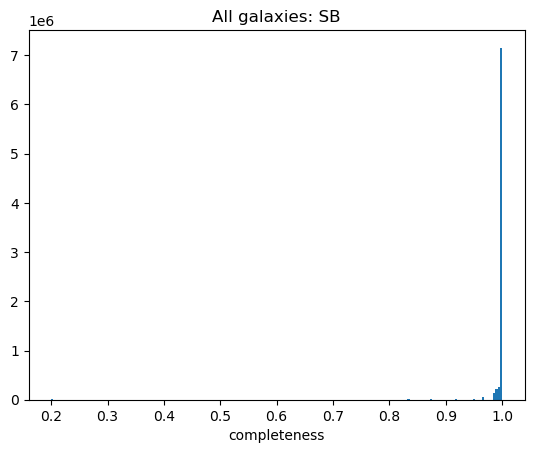

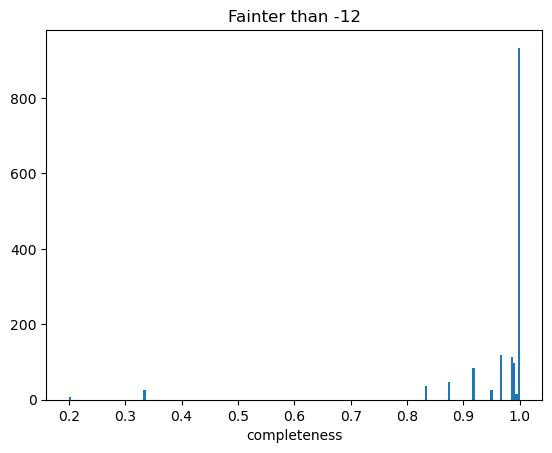

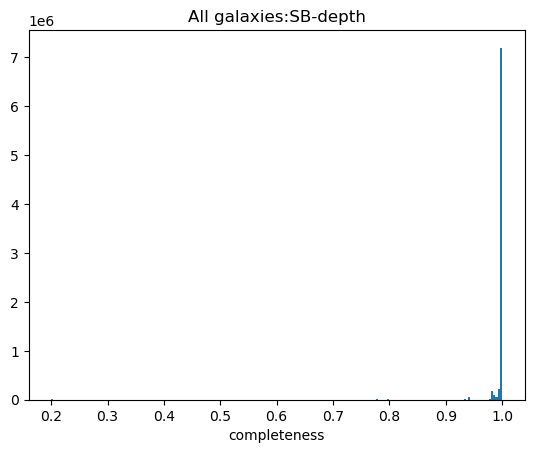

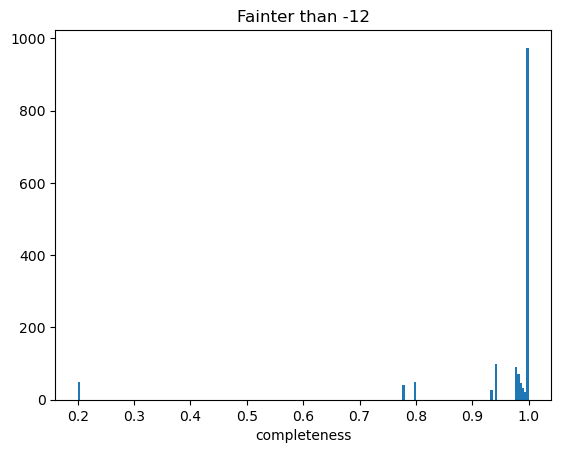

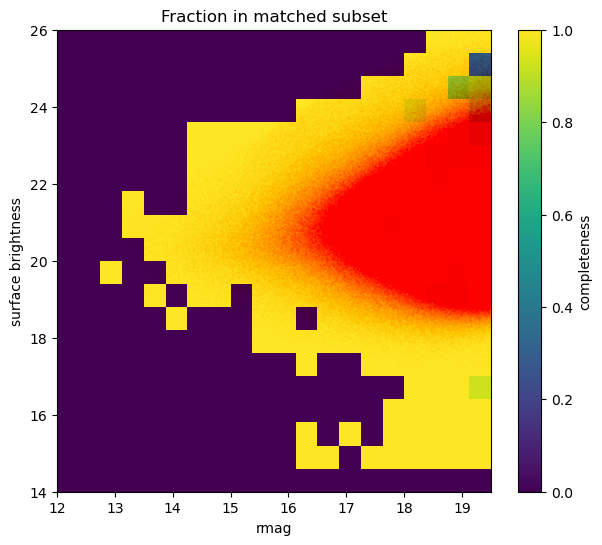

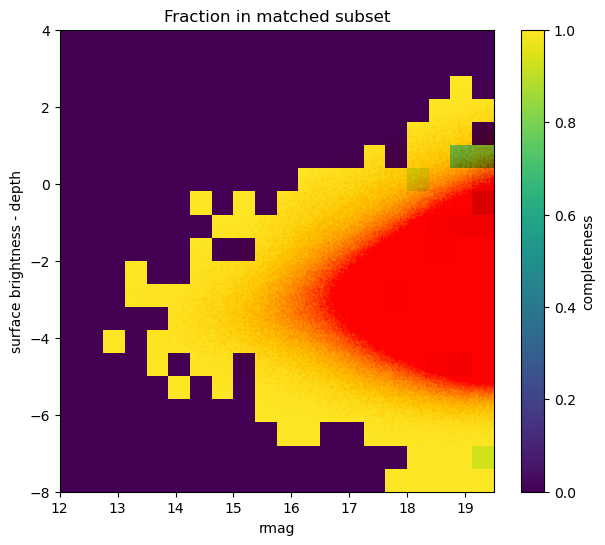

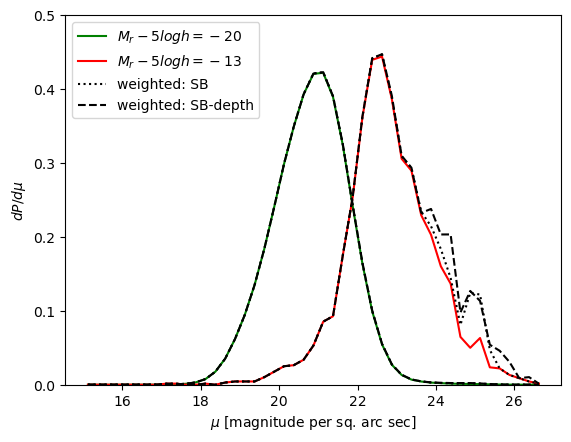

<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213476    0.104427   0.00200603    0.599956
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG

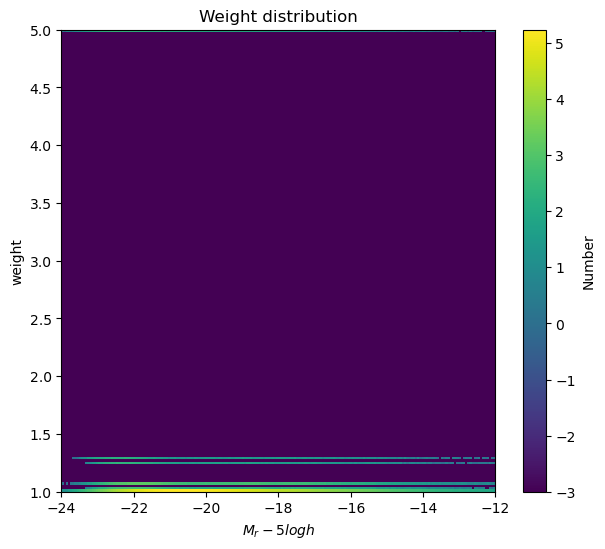

In [15]:
# Load the look-up table
SBcompl = np.load('sdata/Completeness_SB_ns.npz')
# Look up the completeness
compl=completeness_lookup(SBcompl['H'],SBcompl['xedges'],SBcompl['yedges'], dat['rawrmag'], dat['SB'], fill_value=1.0)
mask=(dat['SB']<20.00)  #assume complete for high SB
compl[mask]=1.0
mask=(compl>1.0)        #cap completeness at 1     
compl[mask]=1.0
mask=(compl<1.0/5.0)   # clip completeness at 1/5
compl[mask]=1.0/5.0
dat['weight_SB']=1.0/compl  #set weight to inverse completeness


#Histogram of completeness values
plt.hist(compl,bins=200)
plt.xlabel('completeness')
plt.title('All galaxies: SB')
plt.show()
mask = (dat['ABSMAG_RP1']>-12)
plt.hist(compl[mask],bins=200)
plt.xlabel('completeness')
plt.title('Fainter than -12')
plt.show()

# Load the look-up table
SBmdcompl = np.load('sdata/Completeness_SB-depth_ns.npz')
# Look up the completeness
compl=completeness_lookup(SBmdcompl['H'],SBmdcompl['xedges'],SBmdcompl['yedges'], dat['rawrmag'], dat['SB-depth'], fill_value=1.0)
mask=(dat['SB-depth']<-3.00)  #assume complete for high SB
compl[mask]=1.0
mask=(compl>1.0)        #cap completeness at 1     
compl[mask]=1.0
mask=(compl<1.0/5.0)   # clip completeness at 1/25
compl[mask]=1.0/5.0
dat['weight_SB-depth']=1.0/compl  #set weight to inverse completeness


#Histogram of completeness values
plt.hist(compl,bins=200)
plt.xlabel('completeness')
plt.title('All galaxies:SB-depth')
plt.show()
mask = (dat['ABSMAG_RP1']>-12)
plt.hist(compl[mask],bins=200)
plt.xlabel('completeness')
plt.title('Fainter than -12')
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(SBcompl['xedges'], SBcompl['yedges'], SBcompl['H'].T, cmap='viridis', shading='auto', vmin=0.0, vmax=1.0)
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('completeness')
plt.xlim([12,19.5])
plt.ylim([14,26])
ax.set_xlabel('rmag')
ax.set_ylabel('surface brightness')
ax.set_title('Fraction in matched subset')
plt.scatter(dat['rmag'], dat['SB'],color='red',s=1.0,marker=',',alpha=0.002,linewidth=0,label='All')
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(SBmdcompl['xedges'], SBmdcompl['yedges'], SBmdcompl['H'].T, cmap='viridis', shading='auto', vmin=0.0, vmax=1.0)
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('completeness')
plt.xlim([12,19.5])
plt.ylim([-8,4])
ax.set_xlabel('rmag')
ax.set_ylabel('surface brightness - depth')
ax.set_title('Fraction in matched subset')
plt.scatter(dat['rawrmag'], dat['SB-depth'],color='red',s=1.0,marker=',',alpha=0.002,linewidth=0,label='All')
plt.show()



#Histogram of SB for two absolute magnitude slices before and after weighting 
bins = np.arange(15, 27, 0.25) 
bin_cen=(bins[1:]+bins[:-1])/2.0
db=bins[1]-bins[0]

mask=(np.abs(dat['ABSMAG_RP1']+20.0)<0.5)
counts2, _ = np.histogram(dat['SB'][mask], bins=bins, density=False)
norm=counts2.sum()
counts2=counts2/(db*norm)
plt.plot(bin_cen,counts2, linestyle='solid',color='green', label='$M_r-5log h=-20$')
counts1, _ = np.histogram(dat['SB'][mask], bins=bins, density=False, weights=dat["weight_SB"][mask])
counts1=counts1/(db*norm)
#plt.plot(bin_cen,counts1, linestyle='dotted', color='black', label='weighted: SB')
counts1, _ = np.histogram(dat['SB'][mask], bins=bins, density=False, weights=dat["weight_SB-depth"][mask])
counts1=counts1/(db*norm)
#plt.plot(bin_cen,counts1, linestyle='dashed', color='black', label='weighted: SB-depth')

mask=(np.abs(dat['ABSMAG_RP1']+13.0)<0.5) 
counts2, _ = np.histogram(dat['SB'][mask], bins=bins, density=False)
norm=counts2.sum()
counts2=counts2/(db*norm)
plt.plot(bin_cen,counts2, linestyle='solid', color='red', label='$M_r-5log h=-13$')
counts1, _ = np.histogram(dat['SB'][mask], bins=bins, density=False, weights=dat["weight_SB"][mask])
counts1=counts1/(db*norm)
plt.plot(bin_cen,counts1, linestyle='dotted',color='black')
counts1, _ = np.histogram(dat['SB'][mask], bins=bins, density=False, weights=dat["weight_SB-depth"][mask])
counts1=counts1/(db*norm)
plt.plot(bin_cen,counts1, linestyle='dashed',color='black')


mask=(np.abs(dat['ABSMAG_RP1']+20.0)<0.5)
counts2, _ = np.histogram(dat['SB'][mask], bins=bins, density=False)
norm=counts2.sum()
counts2=counts2/(db*norm)
#plt.plot(bin_cen,counts2, linestyle='solid',color='green', label='$M_r-5log h=-20$')
counts1, _ = np.histogram(dat['SB'][mask], bins=bins, density=False, weights=dat["weight_SB"][mask])
counts1=counts1/(db*norm)
plt.plot(bin_cen,counts1, linestyle='dotted', color='black', label='weighted: SB')
counts1, _ = np.histogram(dat['SB'][mask], bins=bins, density=False, weights=dat["weight_SB-depth"][mask])
counts1=counts1/(db*norm)
plt.plot(bin_cen,counts1, linestyle='dashed', color='black', label='weighted: SB-depth')


#mask=(np.abs(dat['ABSMAG_RP1']+23.0)<0.5) 
#counts2, _ = np.histogram(dat['SB'][mask], bins=bins, density=False)
#norm=counts2.sum()
#counts2=counts2/norm
#plt.plot(bin_cen,counts2,marker=',', linestyle='-', label='$M_r-5log h=-23$')
#counts1, _ = np.histogram(dat['SB'][mask], bins=bins, density=False, weights=dat["weight_SB"][mask])
#counts1=counts1/norm
#plt.plot(bin_cen,counts1,marker=',', linestyle='dotted', label='$M_r-5log h=-23 weighted$')
#counts1, _ = np.histogram(dat['SB'][mask], bins=bins, density=False, weights=dat["weight_SB-depth"][mask])
#counts1=counts1/norm
#plt.plot(bin_cen,counts1,marker=',', linestyle='dashed', label='$M_r-5log h=-23 weighted: SB-depth$')

plt.ylim([0,0.5])
plt.xlabel('$\mu$ [magnitude per sq. arc sec]')
plt.ylabel('$dP/d\mu$')
plt.legend()
plt.savefig('SBdist.pdf')
plt.show()




# Distribution of weight as a function of absolute magnitude
nbins=200
xedges = np.linspace(-24, -12, nbins+1)
yedges = np.linspace(1, 5, nbins+1)


# Total counts per 2D bin
H_total, _, _ = np.histogram2d(dat['ABSMAG_RP1'], dat['weight_SB-depth'], bins=[xedges, yedges])
H,_ = np.histogram(dat['ABSMAG_RP1'], bins=xedges)


# Plot with pcolormesh (note transpose: histogram2d returns [xbin, ybin])
fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(xedges, yedges, np.log10(+0.001+H_total.T), cmap='viridis', shading='auto')
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Number')

ax.set_xlabel('$M_r - 5 log h$')
ax.set_ylabel('weight')
ax.set_title('Weight distribution')



if (info):
    dat.info('stats')


starting region  N
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Sample size in this region and between faint and bright apparent magnitude limits: 2438851
Number of cases trapped where the lower bound needs adjusting: 10
Number of cases still trapped where the lower bound needs adjusting: 0
This is the right thing to do when zmax computed from the faint limit is greater than the zmax imposed in the sample selection
Similary it is the right thing to if zmin computed from the bright limit is less than the zmin imposed in the sample selection
root_itp2: maximum number of iterations required= 18
iteration 1 : 2432919  not yet converged
iteration 2 : 2432919  not yet converged
iteration 3 : 2432802  not yet converged
iteration 4 : 2217555  not yet converged
iteration 5 : 833435  not yet converged
iteration 6 : 176178  not yet converged
iteration 7 : 58538  not yet converged
iteration 8 : 27889  not yet converged
iteration 9 : 14509  not yet converged
iteration

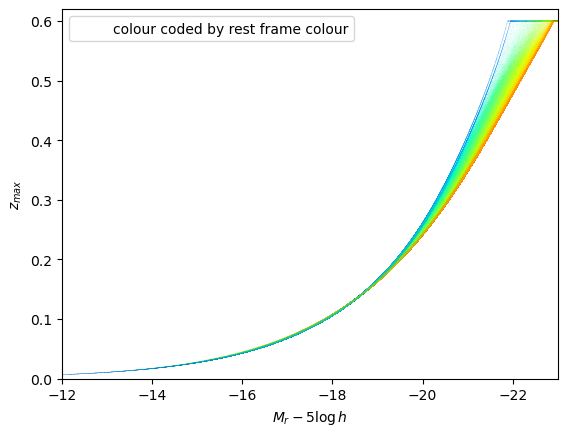

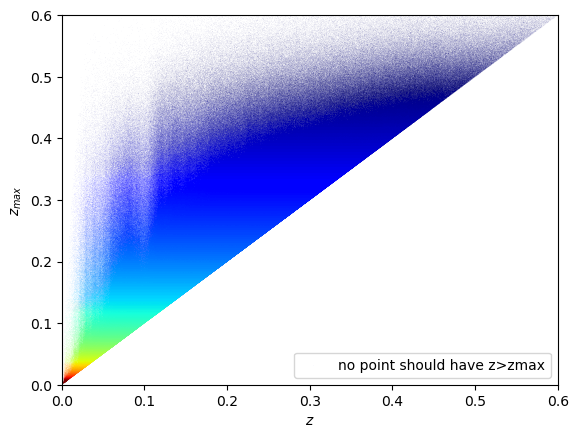

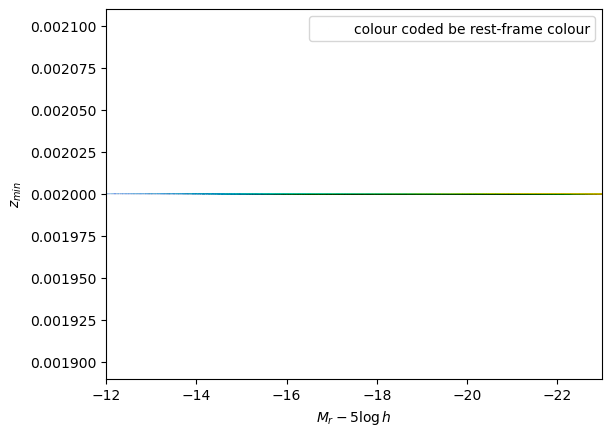

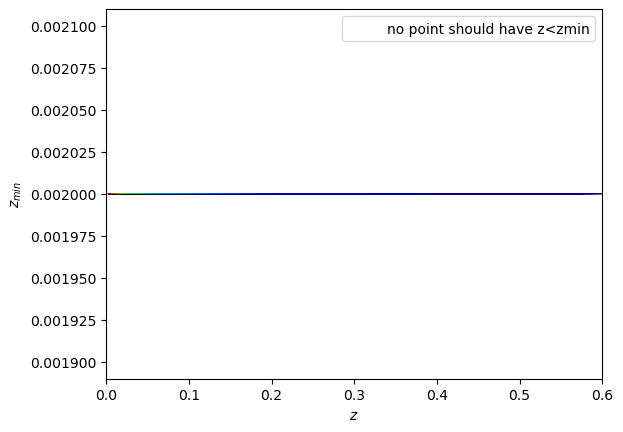

In [16]:
# Compute zmax and vmax values
ca.compute_zmax(dat,regions)
#  
# Make some test plots but avoid plotting data from any unprocessed region
if (len(regions) > 1):
   regmask=  ((dat['reg']=='N') | (dat['reg']=='S'))
else:    
   regmask= (dat['reg']==regions)

plot=True
if plot:    
    #Plots of how zmax depends on absolute magnitude, colour and redshift
    ca.plot_zmax_absmag(dat[regmask])
    ca.plot_zmax_z(dat[regmask])
    #Plots of how zmin depends on absolute magnitude, colour and redshift
    ca.plot_zmin_absmag(dat)
    ca.plot_zmin_z(dat[regmask])

   

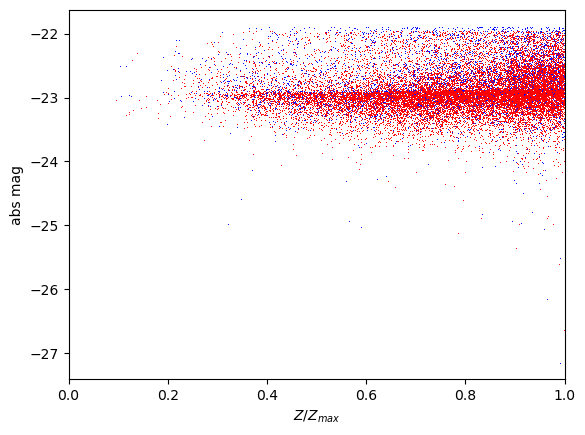

In [17]:
for reg in regions:
    Sel=ca.selection(reg) # define selection parameters for this region
    regmask=(dat['reg']==reg)#mask to select objects in specified region    
    mask = (regmask) & (dat['zmax']==0.6)
    
    plt.scatter(dat['Z'][mask]/dat['zmax'][mask],dat['ABSMAG_RP1'][mask], marker='.' ,linewidths=0,s=2.0,alpha=1.0,color=Sel['col'])
   
plt.xlabel('$Z/Z_{max}$')
plt.ylabel('abs mag')
plt.xlim([0,1.0])
#plt.legend()
plt.show()

In [18]:
#Add vmin,vmax computer from zmin zmax
ca.add_vminvmax(dat,regions)  

starting region  N
starting region  S


In [19]:
# Write the Augmented table to a fits file 
# Add meta data to store the selection cuts used in defining this sample and other information
Sel=ca.selection('N')
dat.meta['Qevol_N']=Sel['Qevol']
dat.meta['Qg_N']=Sel['Qg']
dat.meta['Qr_N']=Sel['Qr']
dat.meta['Qz_N']=Sel['Qz']
dat.meta['Qw1_N']=Sel['Qw1']
dat.meta['zmax_N']=Sel['zmax']
dat.meta['zmin_N']=Sel['zmin']
dat.meta['bright_N']=Sel['bright']
dat.meta['faint_N']=Sel['faint']
dat.meta['area_N']=Sel['area']
dat.meta['f_ran_N']=Sel['f_ran']
dat.meta['col_N']=Sel['col']
dat.meta['style_N']=Sel['style']

Sel=ca.selection('S')
dat.meta['Qevol_S']=Sel['Qevol']
dat.meta['Qg_S']=Sel['Qg']
dat.meta['Qr_S']=Sel['Qr']
dat.meta['Qz_S']=Sel['Qz']
dat.meta['Qw1_S']=Sel['Qw1']
dat.meta['zmax_S']=Sel['zmax']
dat.meta['zmin_S']=Sel['zmin']
dat.meta['bright_S']=Sel['bright']
dat.meta['faint_S']=Sel['faint']
dat.meta['area_S']=Sel['area']
dat.meta['f_ran_S']=Sel['f_ran']
dat.meta['col_S']=Sel['col']
dat.meta['style_S']=Sel['style']
#
# Store the parameters of the cosmology used to make this catalogue
dat.meta['H0']=ca.cosmo.H0.value
dat.meta['Tcmb0']=ca.cosmo.Tcmb0.value
dat.meta['Om0']=ca.cosmo.Om0
#
# Store the choices made for some of the processing option flags
dat.meta['PMatch']=PhotometryMatch
dat.meta['ZFLOW']=UseCosmicRedshift
dat.meta['petrosian']=UsePetrosian
# Write the table complete with its meta data
#
dat.write(OutputCatalogue,overwrite=True) 


In [20]:
# quick look at the stats of the final augmented data set
dat.info('stats')


<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213476    0.104427   0.00200603    0.599956
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG